In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
!pip install mlflow xgboost -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 64.0 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 67.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 42.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 907.5/907.5 kB 24.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 9.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import mlflow
import mlflow.sklearn

In [3]:
np.random.seed(42)

n_samples = 10000

temperature = np.random.normal(75,15,n_samples)
vibration = np.random.normal(0.5,0.2,n_samples)
pressure = np.random.normal(100,20,n_samples)
rpm = np.random.normal(1500,200,n_samples)
age_days = np.random.randint(0,365,n_samples)

failure_score = (
    (temperature > 90)*0.3 +
    (vibration > 0.8)*0.3 +
    (pressure > 130)*0.2 +
    (age_days > 300)*0.2
)

failure_prob = failure_score + np.random.normal(0,0.1,n_samples)

failure = (failure_prob > 0.35).astype(int)

data = pd.DataFrame({
    'temperature': temperature,
    'vibration': vibration,
    'pressure': pressure,
    'rpm': rpm,
    'age_days': age_days,
    'failure': failure
})

print("Dataset Shape:", data.shape)
print("Failure Rate:", round(data.failure.mean()*100,2), "%")

data.head()

Dataset Shape: (10000, 6)
Failure Rate: 12.74 %


,temperature,vibration,pressure,rpm,age_days,failure
0,82.450712,0.364301,106.965725,1103.885606,187,0
1,72.926035,0.438900,105.666472,1289.002871,239,0
2,84.715328,0.380524,81.269603,1382.594319,2,0
3,97.845448,0.522084,111.591684,1529.933782,5,0
4,71.487699,0.739436,70.198346,1704.832465,259,0


In [4]:
print(data.describe())

        temperature     vibration      pressure           rpm      age_days  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean      74.967960      0.502707     99.750745   1498.485705    181.908000   
std       15.051936      0.200202     19.828363    200.897414    105.568632   
min       16.163996     -0.271275     26.898270    606.879227      0.000000   
25%       64.911142      0.367598     85.996962   1361.077430     90.000000   
50%       74.961075      0.503169     99.884635   1497.923551    182.000000   
75%       85.066213      0.638773    113.277949   1635.806091    272.000000   
max      133.893566      1.395817    173.832490   2245.566669    364.000000   

            failure  
count  10000.000000  
mean       0.127400  
std        0.333437  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        0.000000  
max        1.000000  


In [5]:
print(data.isnull().sum())

temperature    0
vibration      0
pressure       0
rpm            0
age_days       0
failure        0
dtype: int64


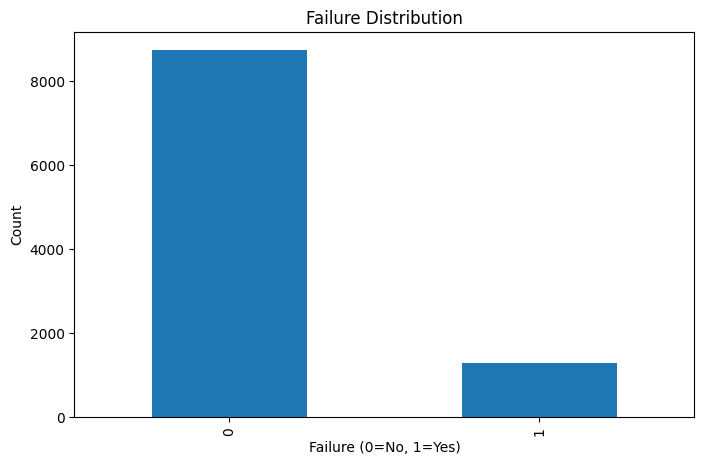

In [6]:
plt.figure(figsize=(8,5))

data.failure.value_counts().plot(kind='bar')

plt.title('Failure Distribution')
plt.xlabel('Failure (0=No, 1=Yes)')
plt.ylabel('Count')

plt.show()

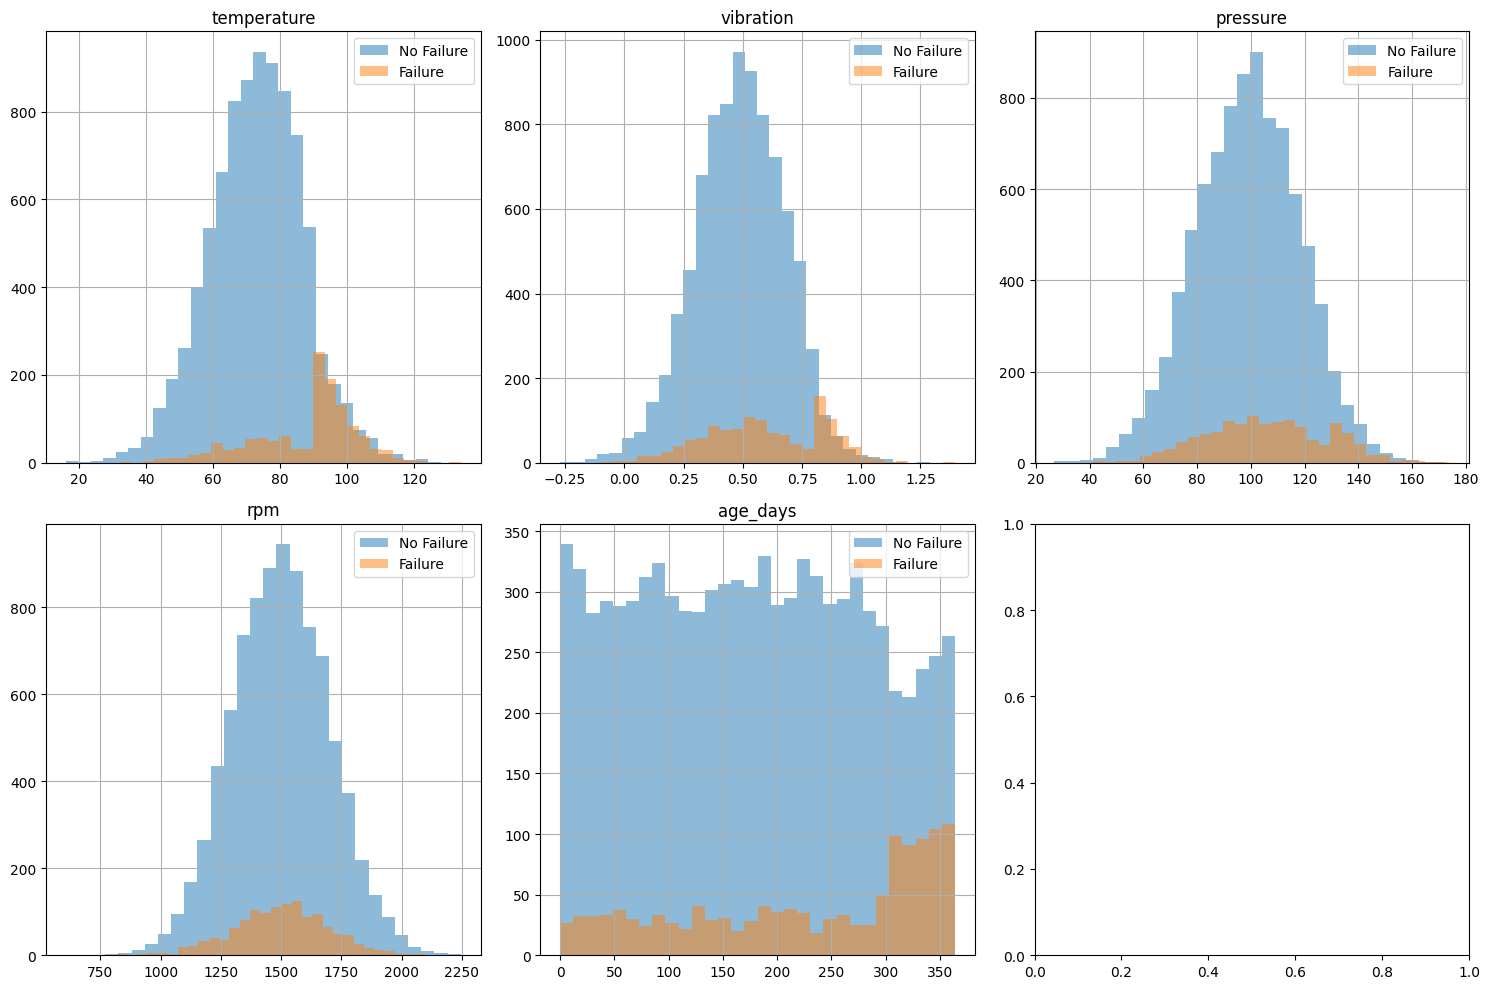

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15,10))

features = [
    'temperature',
    'vibration',
    'pressure',
    'rpm',
    'age_days'
]

for idx, feature in enumerate(features):

    ax = axes[idx//3, idx%3]

    data[data.failure==0][feature].hist(
        ax=ax,
        alpha=0.5,
        label='No Failure',
        bins=30
    )

    data[data.failure==1][feature].hist(
        ax=ax,
        alpha=0.5,
        label='Failure',
        bins=30
    )

    ax.set_title(feature)
    ax.legend()
plt.tight_layout()
plt.show()

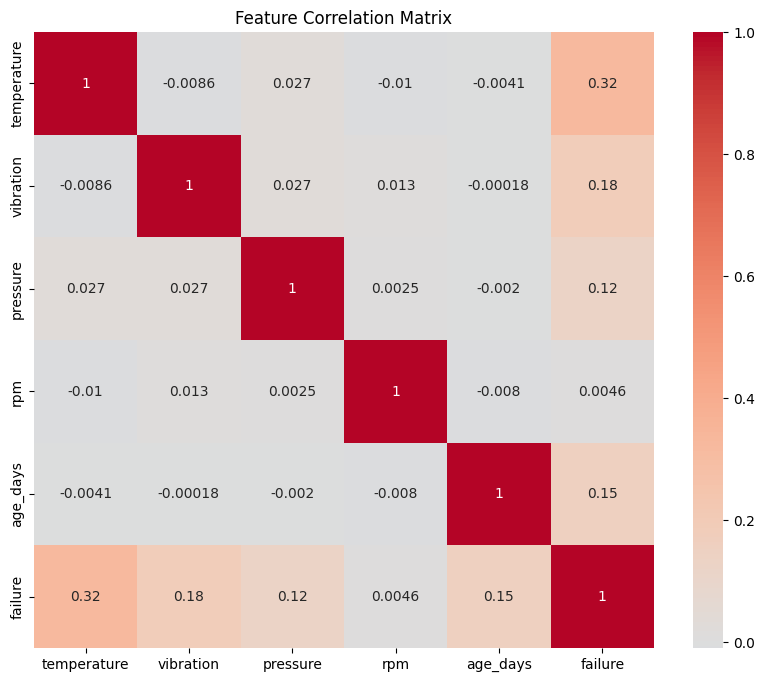

In [8]:
plt.figure(figsize=(10,8))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

In [9]:
mlflow.set_experiment("predictive-maintenance")

print("Experiment Created")

2026/06/06 10:15:01 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/06 10:15:01 INFO mlflow.store.db.utils: Updating database tables
2026/06/06 10:15:04 INFO mlflow.tracking.fluent: Experiment with name 'predictive-maintenance' does not exist. Creating a new experiment.


Experiment Created


In [10]:
X = data.drop('failure', axis=1)
y = data['failure']

print(X.shape)
print(y.shape)


(10000, 5)
(10000,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (8000, 5)
Testing Set: (2000, 5)


In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Complete")

Scaling Complete


In [13]:
with mlflow.start_run(run_name="logistic_regression"):

    C = 1.0
    max_iter = 1000

    mlflow.log_param("C", C)
    mlflow.log_param("max_iter", max_iter)
    mlflow.log_param("model_type", "LogisticRegression")

    model = LogisticRegression(
        C=C,
        max_iter=max_iter,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:,1]

    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    roc_auc = roc_auc_score(y_test,y_prob)

    mlflow.log_metric("accuracy",accuracy)
    mlflow.log_metric("precision",precision)
    mlflow.log_metric("recall",recall)
    mlflow.log_metric("f1_score",f1)
    mlflow.log_metric("roc_auc",roc_auc)
    
    print("Logistic Regression")
    print("Accuracy:",accuracy)
    print("F1:",f1)
    print("ROC AUC:",roc_auc)
    lr_auc = roc_auc


Logistic Regression
Accuracy: 0.887
F1: 0.3687150837988827
ROC AUC: 0.8460205629529749


In [14]:
with mlflow.start_run(run_name="random_forest"):

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        random_state=42
    )

    model.fit(X_train_scaled,y_train)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:,1]

    accuracy = accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    roc_auc = roc_auc_score(y_test,y_prob)

    print("Random Forest")
    print("Accuracy:",accuracy)
    print("F1:",f1)
    print("ROC AUC:",roc_auc)
    rf_auc = roc_auc

Random Forest
Accuracy: 0.9245
F1: 0.6253101736972705
ROC AUC: 0.9421900106747569


In [15]:
with mlflow.start_run(run_name="xgboost"):

    model = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss'
    )

    model.fit(X_train_scaled,y_train)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:,1]

    accuracy = accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    roc_auc = roc_auc_score(y_test,y_prob)

    print("XGBoost")
    print("Accuracy:",accuracy)
    print("F1:",f1)
    print("ROC AUC:",roc_auc)
    xgb_auc = roc_auc

XGBoost
Accuracy: 0.92
F1: 0.6226415094339622
ROC AUC: 0.9413405247485813


In [16]:
results = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest","XGBoost"],
    "ROC_AUC":[lr_auc, rf_auc, xgb_auc]
})

results.sort_values("ROC_AUC", ascending=False)

,Model,ROC_AUC
1,Random Forest,0.942190
2,XGBoost,0.941341
0,Logistic Regression,0.846021


In [17]:
import joblib

joblib.dump(model,"best_xgboost.pkl")

print("Best model saved")

Best model saved
